In [1]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../../dmri/utils/pyloric.mplstyle")


In [2]:
pits_short_mask = np.load('outputs/coverage_eval2/pit_coverage_mask_all.npz', allow_pickle=True)
pits_short_theta = np.load('outputs/coverage_eval2/pit_coverage_theta_all.npz', allow_pickle=True)
pits_long_mask = np.load('outputs/coverage_eval2/pit_coverage_mask_all_long.npz', allow_pickle=True)
pits_long_theta = np.load('outputs/coverage_eval2/pit_coverage_theta_all_long.npz', allow_pickle=True)
# Access individual arrays
alpha_s = pits_short_mask['alpha']
coverage_s = pits_short_mask['coverage']
coverage_l = pits_long_mask['coverage']
pits_s = pits_short_mask['pits']
pits_l = pits_long_mask['pits']
labels_s = pits_short_mask['labels']
hyperparameters_s = pits_short_mask['hyperparameters']

In [3]:
pits_s.shape

(12, 50000)

In [4]:
alpha = pits_short_theta['alpha']
thetas = pits_short_theta['coverage']
pits = pits_short_theta['pits']
pits_theta_long = pits_long_theta['pits']
labels = pits_short_theta['labels']
theta_mask_counts = pits_short_theta['theta_mask_counts']
theta_mask_coverage = pits_short_theta['theta_mask_coverage']
theta_mask_errors = pits_short_theta['theta_mask_errors']
theta_mask_labels = pits_short_theta['theta_mask_labels']

In [5]:
theta_mask_errors_long = pits_long_theta['theta_mask_errors']

In [6]:
pits_short_theta["hyperparameters"]

array([0.95], dtype=float32)

In [7]:
pits_short_theta["theta_mask_support"]

array([[False, False, False, False, False, False, False, False, False,
        False, False,  True],
       [False, False,  True, False, False, False, False, False, False,
        False, False,  True],
       [ True, False, False,  True, False, False, False, False, False,
        False,  True, False],
       [ True, False, False, False,  True, False, False, False, False,
        False, False,  True],
       [False,  True, False,  True, False, False, False, False, False,
        False,  True, False],
       [False, False, False,  True,  True, False, False, False, False,
        False, False,  True],
       [False,  True, False, False, False,  True, False, False, False,
        False,  True, False],
       [ True,  True, False,  True, False, False, False, False, False,
        False, False,  True],
       [ True,  True,  True, False, False, False, False, False, False,
        False,  True, False],
       [ True, False,  True, False, False,  True, False, False, False,
        False,  True

In [8]:
labels = theta_mask_labels
counts = theta_mask_counts
errors = theta_mask_errors
param_counts = counts
cmap_name = "viridis"  # "plasma"

In [9]:
pits_short_mask

NpzFile 'outputs/coverage_eval2/pit_coverage_mask_all.npz' with keys: alpha, coverage, pits, labels, hyperparameters...

In [10]:
counts

array([20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000,
       20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000,
       20000, 20000])

In [11]:
def random_error(rng, counts):
    u = jax.random.uniform(rng, shape=(counts,))
    ecdf = jnp.quantile(u, alpha)
    lower_bound = jnp.abs(ecdf - alpha).mean(-1)
    return lower_bound

In [12]:
random_error_thetas = [jax.vmap(random_error, in_axes=(0, None))(jax.random.split(jax.random.PRNGKey(42), 1000), counts) for counts in counts]

In [13]:
random_error_thetas_min = jnp.array([jnp.quantile(err, 0.025) for err in random_error_thetas]).min()
random_error_thetas_max  = jnp.array([jnp.quantile(err, 0.975) for err in random_error_thetas]).max()

In [14]:
random_error_mask = jax.vmap(random_error, in_axes=(0, None))(jax.random.split(jax.random.PRNGKey(42), 1000), pits_s.shape[1])

In [15]:
random_error_mask_min = jnp.quantile(random_error_mask, 0.0225)
random_error_mask_max = jnp.quantile(random_error_mask, 0.975)

In [16]:
color1 = '#1b7a52'
color2 = '#2ecf8b'

/tmp/ipykernel_3682527/68019354.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels_sub, rotation=90, ha='right', fontsize=8)


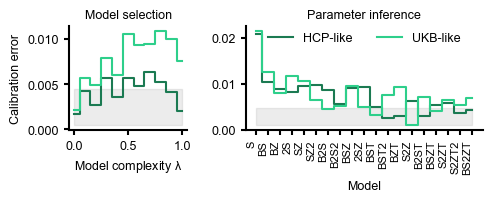

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(5., 2.1), width_ratios=[0.5, 1])
errors_short_mask = [jnp.abs(cov - alpha_s).mean() for cov in coverage_s]
errors_long_mask = [jnp.abs(cov - alpha_s).mean() for cov in coverage_l]

mask_short = ~np.isnan(hyperparameters_s)
axes[0].step(np.asarray(hyperparameters_s)[mask_short], np.asarray(errors_short_mask)[mask_short], color=color1, where='mid', label='n=HCP-like')
axes[0].step(np.asarray(hyperparameters_s)[mask_short], np.asarray(errors_long_mask)[mask_short], color=color2, where='mid', label='n=UKB-like')
axes[0].set_xlabel(r'Model complexity $\lambda$')
axes[0].set_ylabel('Calibration error')
axes[0].set_title('Model selection')
axes[0].fill_between(hyperparameters_s[mask_short],random_error_mask.min(), random_error_mask.max(), color="grey", alpha=0.15)
labels_sub = labels[1:]
labels_sub = [x.replace("#", "") for x in labels_sub]
errors_sub = errors[1:]
errors_long_sub = theta_mask_errors_long[1:]
positions = np.arange(len(labels_sub))
axes[1].step(positions, errors_sub, color=color1, where='mid', label='HCP-like')
axes[1].step(positions, errors_long_sub, color=color2, where='mid', label='UKB-like')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)
axes[1].set_xticklabels(labels_sub, rotation=90, ha='right', fontsize=8)
axes[1].fill_between(positions, random_error_thetas_min, random_error_thetas_max, color="grey", alpha=0.15)
#axes[1].step(labels, random_error_thetas, color="grey", where='mid', label='Random', linestyle='--')
axes[1].set_xlabel('Model')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels_sub, rotation=90, ha='right', fontsize=8)
#axes[1].set_ylabel('Calibration error')
axes[1].set_title('Parameter inference')

#axes[1].grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()
fig.savefig("coverage_plot.png", dpi=300)
fig.savefig("coverage_plot.svg")

/tmp/ipykernel_3682527/959790334.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels_sub, rotation=90, ha='right', fontsize=8)


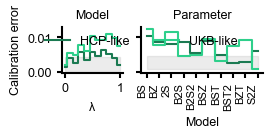

In [33]:

fig, axes = plt.subplots(1, 2, figsize=(2.6, 0.6), width_ratios=[0.5, 1], sharey=True)
errors_short_mask = [jnp.abs(cov - alpha_s).mean() for cov in coverage_s]
errors_long_mask = [jnp.abs(cov - alpha_s).mean() for cov in coverage_l]

mask_short = ~np.isnan(hyperparameters_s)
axes[0].step(np.asarray(hyperparameters_s)[mask_short], np.asarray(errors_short_mask)[mask_short], color=color1, where='mid', label='n=HCP-like')
axes[0].step(np.asarray(hyperparameters_s)[mask_short], np.asarray(errors_long_mask)[mask_short], color=color2, where='mid', label='n=UKB-like')
axes[0].set_xlabel(r'$\lambda$')
axes[0].set_ylabel('Calibration error')
axes[0].set_title('Model')
axes[0].fill_between(hyperparameters_s[mask_short],random_error_mask.min(), random_error_mask.max(), color="grey", alpha=0.15)
idx_sub = [2,3,4,7,8,9, 11, 12, 13,14]
labels_sub = labels[idx_sub]
labels_sub = [x.replace("#", "") for x in labels_sub]
errors_sub = errors[idx_sub]
errors_long_sub = theta_mask_errors_long[idx_sub]
positions = np.arange(len(labels_sub))
axes[1].step(positions, errors_sub, color=color1, where='mid', label='HCP-like')
axes[1].step(positions, errors_long_sub, color=color2, where='mid', label='UKB-like')
axes[1].legend(loc='upper center', bbox_to_anchor=(0., 1.05), ncol=2, frameon=False, labelspacing=0.1)
axes[1].set_xticklabels(labels_sub, rotation=90, ha='right', fontsize=8)
axes[1].fill_between(positions, random_error_thetas_min, random_error_thetas_max, color="grey", alpha=0.15)
#axes[1].step(labels, random_error_thetas, color="grey", where='mid', label='Random', linestyle='--')
axes[1].set_xlabel('Model')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels_sub, rotation=90, ha='right', fontsize=8)
#axes[1].set_ylabel('Calibration error')
axes[1].set_title('Parameter')

#axes[1].grid(True, linestyle='--', alpha=0.3)
#fig.tight_layout()
fig.savefig("small_coverage_plot.svg")

In [19]:
overal_cov = jnp.quantile(pits_s.reshape(-1), alpha_s)

overal_cov_long = jnp.quantile(pits_l.reshape(-1), alpha_s)  # from long theta

In [20]:
overal_theta_cov = jnp.quantile(pits.reshape(-1), alpha_s)
overal_theta_cov_long = jnp.quantile(pits_theta_long.reshape(-1), alpha_s)

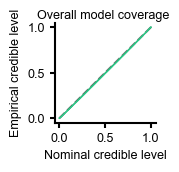

In [21]:
fig = plt.figure(figsize=(1.3,1.3))
plt.plot(alpha, alpha, linestyle='--', color='grey')
plt.plot(alpha, overal_cov, color=color1, lw =1)
plt.plot(alpha, overal_cov_long, color=color2, lw=1)
plt.xticks([0.0, 0.5, 1.0])
plt.yticks([0.0, 0.5, 1.0])
plt.xlabel('Nominal credible level')
plt.ylabel('Empirical credible level')
fig.suptitle('Overall model coverage')
fig.savefig("overall_model_coverage.svg", dpi=300)

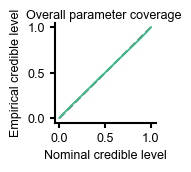

In [22]:
fig = plt.figure(figsize=(1.3,1.3))
plt.plot(alpha, alpha, linestyle='--', color='grey')
plt.plot(alpha, overal_theta_cov, color=color1, lw=1)
plt.plot(alpha, overal_theta_cov_long, color=color2, lw=1)
plt.xticks([0.0, 0.5, 1.0])
plt.yticks([0.0, 0.5, 1.0])
plt.xlabel('Nominal credible level')
plt.ylabel('Empirical credible level')
fig.suptitle('Overall parameter coverage')
fig.savefig("overall_param_coverage.svg", dpi=300)

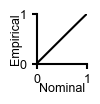

In [23]:
fig = plt.figure(figsize=(0.65, .65))

plt.plot(alpha_s, coverage_s.mean(0), color="black")
plt.xlabel('Nominal', labelpad=-2.5)
plt.ylabel('Empirical', labelpad=-1.5)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xticks([0,1], [0,1])
plt.yticks([0,1], [0,1])
fig.savefig("small_model_coverage.svg", dpi=300, bbox_inches='tight', transparent=True)

In [25]:
overal_theta_cov.shape

(101,)

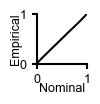

In [27]:
fig = plt.figure(figsize=(0.65, .65))

plt.plot(alpha, overal_theta_cov, color="black")
plt.xlabel('Nominal', labelpad=-2.5)
plt.ylabel('Empirical', labelpad=-1.5)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xticks([0,1], [0,1])
plt.yticks([0,1], [0,1])
fig.savefig("small_parameter_coverage.svg", dpi=300, bbox_inches='tight', transparent=True)